# Module 9 — PII, Deterministic Routing and Metadata-Only Audit Controls

**Question.** Do the registered controls behave deterministically on synthetic challenge cases while preventing Module 8's failed uncertainty thresholds from authorizing automated suggestions?

**Success criteria.** Every expected redaction and route must match, all registered PII detector classes must be exercised, no `suggest_queue` action may occur, audit events must round-trip without message text or message hashes, and the local evidence sink must use `0700/0600` permissions.

**Claim boundary.** This notebook reads one text-free summary report. It does not load the synthetic messages, BANKING77, model weights, logits, or customer data. Passing these tests verifies the registered implementation against bounded fixtures; it is not production validation.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "reports/governance/module9-controls.json").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the project repository")

ROOT = find_repository_root(Path.cwd().resolve())
REPORT_PATH = ROOT / "reports/governance/module9-controls.json"
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
ROOT.name

'governed-banking-intent-router'

## 1. Verify the evidence boundary

The artifact must be metadata-only and must distinguish synthetic control verification from production or model-quality evidence.

In [2]:
pd.Series({
    "Claim scope": report["claim_scope"],
    "Synthetic provenance": report["source_evidence"]["provenance"],
    "Contains message text": report["contains_message_text"],
    "Contains redacted text": report["contains_redacted_text"],
    "Contains message hash": report["contains_message_hash"],
    "Model inference performed": report["model_inference_performed"],
    "Official-test metrics computed": report["official_test_metrics_computed"],
}).to_frame("Registered value")

,Registered value
Claim scope,synthetic_control_verification_not_production_...
Synthetic provenance,synthetic_authored_non_customer_data
Contains message text,False
Contains redacted text,False
Contains message hash,False
Model inference performed,False
Official-test metrics computed,False


## 2. Structured-PII control coverage

These counts show fixture coverage, not detector precision or recall on real banking traffic. Positive and negative expectations are both asserted by the executable evidence run.

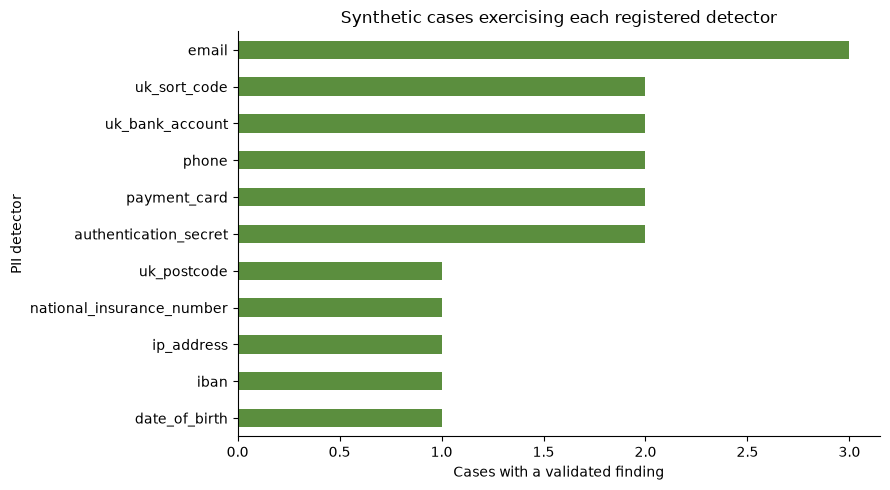

,Result
Total cases,23
Expected detections,16
Expected non-detections,7
Missing detector classes,0
All expected outputs matched,True


In [3]:
privacy = report["privacy"]
detector_counts = pd.Series(privacy["detector_case_counts"]).sort_values()
ax = detector_counts.plot.barh(figsize=(9, 5), color="#5B8E3E")
ax.set_title("Synthetic cases exercising each registered detector")
ax.set_xlabel("Cases with a validated finding")
ax.set_ylabel("PII detector")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
pd.Series({
    "Total cases": privacy["case_count"],
    "Expected detections": privacy["expected_detection_cases"],
    "Expected non-detections": privacy["expected_non_detection_cases"],
    "Missing detector classes": len(privacy["missing_registered_detectors"]),
    "All expected outputs matched": privacy["all_expected_outputs_matched"],
}).to_frame("Result")

## 3. Deterministic routing under a failed uncertainty gate

Security intents and exposed authentication secrets go to the security queue. Every other registered case goes to human review. Module 8 confidence is recorded only as an experimental observation.

In [4]:
routing = report["routing"]
pd.Series({
    "Operating mode": routing["operating_mode"],
    "Cases": routing["case_count"],
    "Human review": routing["action_counts"].get("human_review", 0),
    "Security queue": routing["action_counts"].get("security_queue", 0),
    "Suggestion queue": routing["suggest_queue_count"],
    "Module 8 status": routing["uncertainty_evidence_status"],
    "Module 8 permitted use": routing["uncertainty_use"],
    "Uncertainty can authorize suggestion": routing["uncertainty_authorized_suggestion"],
}).to_frame("Registered result")

,Registered result
Operating mode,shadow_review_only
Cases,8
Human review,6
Security queue,2
Suggestion queue,0
Module 8 status,failed_registered_gates
Module 8 permitted use,review_signal_only
Uncertainty can authorize suggestion,False


## 4. Metadata-only audit evidence

The local JSONL sink is an implementation demonstration. Production still requires centralized authorization, retention, integrity protection and operational monitoring.

In [5]:
audit = report["audit"]
pd.Series({
    "Validated events": audit["event_count"],
    "Round trip validated": audit["validated_round_trip"],
    "Original/redacted value matches": audit["prohibited_value_matches"],
    "Message hash logged": audit["message_hash_logged"],
    "Exact input length logged": audit["exact_input_length_logged"],
    "Directory mode": audit["directory_mode"],
    "File mode": audit["file_mode"],
}).to_frame("Result")

,Result
Validated events,24
Round trip validated,True
Original/redacted value matches,0
Message hash logged,False
Exact input length logged,False
Directory mode,0700
File mode,0600


## 5. Acceptance decision

In [6]:
gates = pd.Series(report["acceptance_gate"]).rename_axis("Control").to_frame("Passed")
assert gates["Passed"].all(), "A registered Module 9 control failed"
gates

,Passed
Control,
all_expected_redactions_matched,True
all_expected_routes_matched,True
all_passed,True
all_registered_detectors_exercised,True
metadata_only_audit_round_trip,True
module8_thresholds_remain_review_only,True
no_original_or_redacted_values_in_audit,True
no_suggestion_actions,True
restrictive_sink_permissions,True


## Interpretation and next step

The registered synthetic checks passed, so the bounded control implementation is suitable for integration into a local shadow-mode API. This does **not** approve automated customer routing: the PII fixture is small and synthetic, regex controls are incomplete, the audit sink is local, and Module 8 failed its selective-risk and possible-OOD gates.

Module 10 should expose this pipeline through FastAPI while preserving pre-inference redaction, fail-closed routing, metadata-only auditing and the no-automation boundary.